# Detecting XLEAP from Undulator K-Taper

**A data-driven detector that identifies XLEAP, quantifies the undulator taper in MeV/fs, and reports the lasing undulators, from archived $K$ and beam-energy snapshots.**

*N. Mamais, LCLS. 2026-07-01*

---

**Abstract.** X-ray Laser-Enhanced Attosecond Pulse generation (XLEAP) imprints a characteristic *taper* on the undulator line: a monotonic ramp in the deflection parameter $K$ across a run of undulators. This notebook reconstructs, for every archived snapshot, (i) whether such a tapered lasing group exists, (ii) which undulators participate, and (iii) the taper expressed as resonant-energy gain per slippage length in MeV/fs. All physics lives in the [`taper`](taper/) package; the notebook is a thin, reproducible driver over the long-form `snapshots.csv`. We validate the pipeline on the SXR soft line (June 2026), characterise a class of high-taper false positives, and show that they arise from off-nominal beam energy rather than undulator motion.

**Reference:** K.-J. Kim, Z. Huang, and R. Lindberg, *Undulator Radiation*, in *Synchrotron Radiation and Free-Electron Lasers*, Cambridge University Press, 2017, pp. 43 to 45.

## 1. Introduction

In an undulator-based free-electron laser the beam radiates at a resonant wavelength set by the beam energy $\gamma$ and the undulator deflection parameter $K$. **XLEAP** drives the machine into a regime where a short current spike lases while a deliberate *taper*, a controlled increase of $K$ from one undulator to the next, keeps the radiation resonant with the energy-chirped slices of the spike. Operationally, XLEAP therefore shows up as a **"hockey stick"** in the $K$ profile: a flat head followed by a monotonic ramp over several consecutive undulators.

Our task is to turn the machine's archived history into a physically meaningful timeline. For each nominal snapshot time we answer three questions:

1. **Is XLEAP happening?** Does a lasing group of $\ge 4$ tapered undulators exist?
2. **Which undulators lase?** Reported as a `{undulator: K}` map.
3. **What is the taper?** The first (most-upstream) group's taper in **MeV/fs**, from the median $\Delta K$, the group's first $K$, and the beam $\gamma$.

The remainder of the notebook derives the taper from first principles (Section 2), describes the data pipeline and detection algorithm (Section 3), presents the reconstructed timeline (Section 4), validates the result and the motion filter (Section 5), and collects the open physics questions (Section 6).

## 2. Theory

In an undulator with magnetic field strength $B_0$ and wavenumber $k_u$, the electrons encounter a magnetic field in $\hat y$

$$
\vec{B}_u = B_0 \sin(k_u z) \hat y
$$

that produces a force in $\hat x$:

$$
\begin{align*}
\dot {\vec p} = \partial_t (\gamma mc \vec \beta)&= -e (\xcancel{\vec E} + \vec v \times \vec B) \\
&= -e(\beta c \hat z) \times B_0 \sin(k_u z) \hat y \\
&= +e\beta c B_0 \sin(k_u z) \hat x \\
\end{align*}
$$
Neglecting energy losses from steering radiation, we take $\dot \gamma = 0$ and integrate (taking $\beta_x = 0$ at $t=0$ from before the undulator) to find $\beta_x$:
$$
\begin{align*}
\dot \beta_x &= \frac{e \beta c B_0}{\gamma m c} \sin(k_u z) = \frac{e \beta B_0}{\gamma m} \sin(k_u \beta c t) \tag{$\beta_z \approx \beta \lesssim 1$} \\
\beta_x &= \left. \frac{e \beta B_0}{\gamma m k_u \beta c} \cos(k_u \beta c t)\right \vert_0^t = \frac{e B_0}{\gamma k_u m c} \cos(k_u \beta c t) - 0 = \frac{1}{\gamma}{\frac{e B_0}{k_u m c}}\cos(k_u z)  \\
\beta_x &= \frac{K}{\gamma} \cos(k_u z) \; \llap{\boxed{\phantom{\beta_x = \frac{K}{\gamma} \cos(k_u z)}}} \tag{$K \coloneqq {e B_0}/{k_u m c}$}
\end{align*}
$$

Again neglecting energy losses from steering radiation, we say that energy $\gamma mc^2$ and therefore total velocity $\beta$ is conserved from before the undulator, but once inside the undulator, the velocity is split between $x$ and $z$ components:

$$
\begin{align*}
{\vec \beta}^2 &= \beta_z^2 + \beta_x^2 \\
\beta_z^2 &= \vec \beta^2 - \beta_x^2 = \left(1 - \frac {1}{\gamma^2} \right) - \beta_x^2 \\
\beta_z &= \sqrt{1-\frac{1}{\gamma^2}-\beta_x^2} \\
&\approx 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\cos^2(k_u z) \tag{$\sqrt{1-\varepsilon}\approx 1-\varepsilon/2$} \\
\left\langle \beta_z \right\rangle &= 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\left\langle\cos^2({k_u z})\right\rangle = 1- \frac{1}{2\gamma^2} - \frac{K^2}{4\gamma^2} \\
\left\langle \beta_z \right\rangle &= 1- \left(\frac{1+K^2/2}{2\gamma^2}\right) \; \llap{\boxed{\phantom{\left\langle \beta_z \right\rangle = 1- \left(\frac{1+K^2/2}{2\gamma^2}\right)}}}
\end{align*}
$$
Therefore, the radiation emitted by the electrons is faster than the electrons themselves by $\Delta \beta \coloneqq 1-\left\langle \beta_z \right\rangle = (1+K^2/2)/2\gamma^2$.

The electrons now experience fields due to both the undulator magnets and their own radiation. To achieve resonance, these contributions must be in phase, so the radiation must slip ahead of the electrons by one radiation wavelength $\lambda_r$ per undulator period $\lambda_u$. Light traverses an undulator period in time $T = \lambda_u/c$, during which time the electrons fall behind by a distance $\Delta \beta c T = \lambda_u(1+K^2/2)/2\gamma^2$, called the **slippage length**. Therefore we set the radiation wavelength equal to one slippage length:
$$
\boxed{\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)}
$$

Meanwhile, space charge forces create an energy spread within the current spike by pushing head electrons forward and tail electrons backward, so the radiation slips ahead from lower-energy to higher-energy slices of electrons: $\gamma \to \gamma + \Delta \gamma$. Due to the taper, $K$ also increases downstream: $K \to K + \Delta K$. To maintain resonance, we now need
$$
\lambda_r = \frac{\lambda_u}{2(\gamma + \Delta \gamma)^2}\left(1+\frac{(K + \Delta K)^2}{2}\right)
$$

Therefore, given a $\Delta K$ between two undulators, we can find the corresponding $\Delta \gamma$ needed to maintain resonance:
$$
\begin{align*}
\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right) &= \frac{\lambda_u}{2(\gamma+\Delta \gamma)^2}\left(1+\frac{(K+\Delta K)^2}{2}\right) \\
\implies \Delta \gamma &= \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right) \; \llap{\boxed{\phantom{\Delta \gamma = \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right)}}} \approx \gamma\left(\frac{K\Delta K + \Delta K^2/2}{K^2+2}\right)
\end{align*}
$$

Finally, we define *undulator taper* as change in resonant energy $\gamma$ per slippage length $\lambda_r$. Since we find $\Delta K$ between undulators and we get $N_u = L_u/\lambda_u$ periods per undulator ($L_u = 3.4 \text{ m}$), we divide $\Delta \gamma$ by the total slippage in one undulator $\Delta s \coloneqq N_u \lambda_r$. However, we write the slippage length in units of time, $N_u \lambda_r/c$, so that we can write the result in MeV/fs.
$$
\mathrm{taper} \coloneqq \frac{\Delta \gamma}{\Delta s} = \frac{\Delta \gamma}{N_u \lambda_r/c} = \frac{\Delta \gamma \lambda_u c}{L_u} \left[\frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)\right]^{-1} = \frac{2 \gamma^2 \Delta \gamma c}{L_u(1+K^2/2)}
$$

Surprisingly, $\lambda_u$ cancels, so we can get the taper from the list of $K$ values (which also gives $\Delta K \to \Delta \gamma$), the beam energy $\gamma$, and the length of an undulator $L_u = 3.4\text{ m}$. These relations live in [`taper/physics.py`](taper/physics.py) as `dk_to_dgamma`, `slippage_time_s`, and `taper_mev_per_fs`.

### 2.1 The $\gamma^3$ scaling (important for Section 5)

Because $\Delta\gamma \propto \gamma$, the taper carries a strong **cubic** dependence on beam energy:
$$
\mathrm{taper} \;\propto\; \gamma^{2}\,\Delta\gamma \;\propto\; \gamma^{3}.
$$
A given $K$-ramp therefore produces a taper that grows like $\gamma^3$. The *same* ramp at $15.7$ GeV/c rather than $10$ GeV/c is about $(15.7/10)^3\approx 3.9$ times larger from energy alone. As Section 5 shows, this is exactly why an ordinary $\Delta K$ can read as a $\sim700$ MeV/fs taper when the machine is at off-nominal energy, and why a *flat* taper ceiling would be the wrong way to reject such points.

## 3. Methods

### 3.1 Data pipeline and the beamline switch

The tool cleanly separates **fetch** from **analysis**:

| module | role |
|---|---|
| `beamlines` | the single line switch (`HXR` / `SXR`); flip `DEFAULT_LINE` there to change lines |
| `snapshots` | fetch binned PV history from the MEME archive into long `snapshots.csv` |
| `taper.constants` | physical constants and the I/O contract (re-exports `DEFAULT_LINE`) |
| `taper.physics` | pure, vectorized taper math |
| `taper.detect` | lasing-group detection (binary erosion / dilation) |
| `taper.store` | long `snapshots.csv` into wide pandas frames |
| `taper.service` | per-time XLEAP timeline assembly |

Both the fetch default PV list and the analysis PV parsing read the same `beamlines.DEFAULT_LINE`, so they cannot disagree. The long CSV `nominal_time, pv, timestamp, value, moved` is the data source of record, with no SQLite or sparklines dependency.

- **$L_u = 3.4$ m** per undulator; inter-undulator drifts are neglected (negligible slippage without the field coupling $\beta_z$ into $\beta_x$).
- **$\gamma$** comes from the active line's dump PV (`BEND:DMPH:400:BACT` on HXR, `BEND:DMPS:400:BACT` on SXR), the beam momentum $p$ in **GeV/c**: $\gamma = \sqrt{(pc)^2+(mc^2)^2}/mc^2$ with $mc^2=0.511$ MeV.
- **$K$** is each undulator's `KAct`; `store.wide_values` pivots the long CSV into a `time x undulator` matrix ordered upstream to downstream.

The setup cell below loads the data and reports the active line.

In [2]:
from datetime import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd

from taper import (
    SnapshotStore,
    DetectionParams,
    DEFAULT_LINE as LINE,   # active undulator line; flip the ONE switch in beamlines.py
    lasing_kvals,
    first_group,
    gamma_from_momentum_gev,
    dk_to_dgamma,
    taper_mev_per_fs,
    xleap_timeline,
    timeline_frame,
)

print(f"Active line: {LINE.name}   K pattern: {LINE.kact_pattern.pattern}   momentum PV: {LINE.momentum_pv}")

# Load EVERY per-window pull (from scripts/pull_sxr.py) into one store.
PULL_DIR = Path("../data/pulls/sxr")      # notebook cwd = xleap_parser/; adjust if yours differs
paths  = sorted(PULL_DIR.glob("sxr_*.csv"))
frames = [df for p in paths for df in (pd.read_csv(p),) if not df.empty]   # skip empty (pre-LCLS-II) windows
if not frames:
    raise FileNotFoundError(f"no data CSVs in {PULL_DIR.resolve()} — run scripts/pull_sxr.py first")
merged = pd.concat(frames, ignore_index=True)

merged_path = PULL_DIR.parent / "sxr_all.csv"     # one combined file, reusable (in gitignored data/)
merged.to_csv(merged_path, index=False)
store = SnapshotStore.from_csv(merged_path)

print(f"{len(frames)}/{len(paths)} files had data  ->  {len(store.frame):,} rows, "
      f"{store.frame['nominal_time'].nunique()} time points")
store.frame.head()

Active line: SXR   K pattern: USEG:UNDS:(\d+):KAct   momentum PV: BEND:DMPS:400:BACT
30/30 files had data  ->  39,497 rows, 1463 time points


,nominal_time,pv,timestamp,value,moved,spread
0,2025-10-30 13:00:00,BEND:DMPS:400:BACT,2025-10-30 13:00:00,3.800000,False,0.000008
1,2025-10-30 13:00:00,USEG:UNDS:2150:KAct,2025-10-30 13:00:01,3.325705,False,0.000015
2,2025-10-30 13:00:00,USEG:UNDS:2250:KAct,2025-10-30 13:02:00,3.206018,False,0.000010
3,2025-10-30 13:00:00,USEG:UNDS:2350:KAct,2025-10-30 13:00:00,3.238346,False,0.000019
4,2025-10-30 13:00:00,USEG:UNDS:2450:KAct,2025-10-30 13:00:02,3.238345,False,0.000015


### 3.2 Detection: the hockey-stick as a morphological opening

XLEAP is declared when a run of at least **`min_group` = 4** consecutive undulators each step up in $K$ by at least $\rho\cdot\texttt{rho\_scale} = 4\rho$ with $\rho\sim10^{-3}$ (the FEL Pierce parameter). We build the boolean "is this step big enough" mask along the undulator axis, then keep only runs of length $\ge 4$ using **binary erosion followed by dilation**, a morphological *opening*, the vectorized way to say "at least $N$ in a row." The toy example below shows opening discarding the short runs and keeping the length-4 run:

In [3]:
from scipy.ndimage import binary_erosion, binary_dilation


def keep_long_runs(arr, n=4):
    structure = [1] * n
    return binary_dilation(binary_erosion(arr, structure=structure), structure=structure)


keep_long_runs(np.array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1], dtype=bool)).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

`DetectionParams` bundles the thresholds (`rho=1e-3`, `rho_scale=4`, `min_group=4`). `lasing_mask` returns a boolean `time x undulator` frame marking every undulator in a lasing group, including the base undulator just upstream of the first big step (the fencepost correction, since $\Delta K_i$ describes the rise from undulator $i-1$ to $i$, so the group owns one more undulator on its upstream edge). `lasing_kvals` blanks the non-lasing entries to `NaN`.

### 3.3 Taper of a lasing group

For the first (most-upstream) lasing group we take the **median** $\Delta K$ across the group, convert it to $\Delta\gamma$ using the group's first $K$ and the beam $\gamma$, and divide by one undulator's slippage time:
$$
\mathrm{taper} = \frac{\Delta\gamma}{N_u\lambda_r/c} = \frac{2\gamma^2\,\Delta\gamma\,c}{L_u\,(1+K^2/2)}
\qquad\text{(}\texttt{taper\_mev\_per\_fs(dK, K, gamma)}\text{)}.
$$
The **median** rather than the mean makes the estimate robust to the single large step created by the missing undulator slot in the physical lattice.

## 4. Results

`xleap_timeline(store, line=LINE)` returns one `XleapPoint` per nominal time, the documented data object `{ 'datetime', 'xleap_on', 'K_lasing', 'n_und', 'taper', 'moving' }`. The figure below is the full reconstructed timeline over the fetched window: the taper (left axis, blue) and the number of lasing undulators (right axis, orange). Motion-flagged points are force-cleared to `taper = NaN` (Section 5.1). The clean $\sim20$ MeV/fs band is real XLEAP; the isolated spikes up to $\sim730$ MeV/fs are the subject of Section 5.

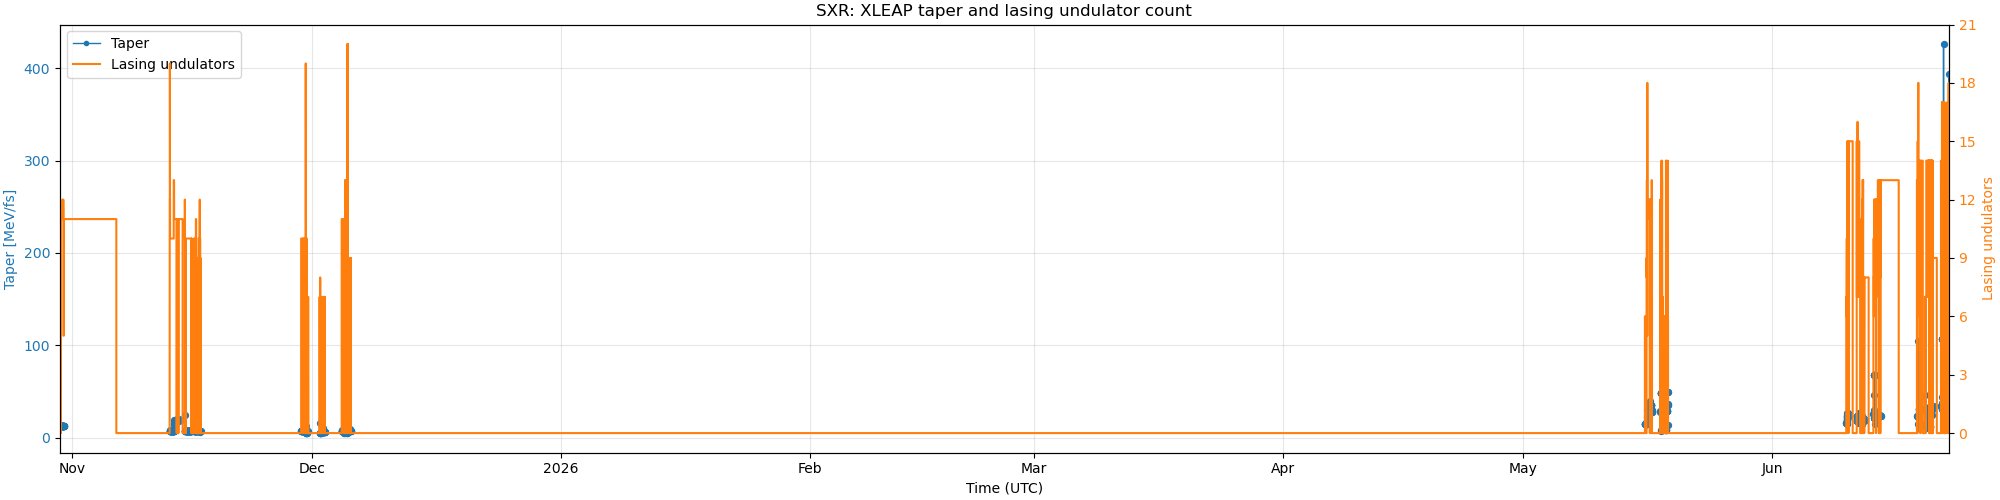

In [18]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

points   = xleap_timeline(store, line=LINE)
xleap_df = timeline_frame(points)

def plot_comparison(taper_ax, df, title, xlo=None, xhi=None):
    """Taper + lasing-undulator dual-axis view on one Axes."""
    und_ax = taper_ax.twinx()
    mask = df["xleap_on"]
    taper_ax.plot(df.index, df["taper"], marker="o", ms=3, lw=1,
                  color="tab:blue", label="Taper")
    und_ax.step(df.index, df["n_und"], where="mid", lw=1.5,
                color="tab:orange", label="Lasing undulators")
    if mask.any():
        taper_ax.scatter(df.index[mask], df.loc[mask, "taper"],
                         s=18, color="tab:blue", zorder=3)
    taper_ax.set_xlim(xlo or df.index.min(), xhi or df.index.max())
    taper_ax.set_title(title)
    taper_ax.set_ylabel("Taper [MeV/fs]", color="tab:blue")
    und_ax.set_ylabel("Lasing undulators", color="tab:orange")
    und_ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    taper_ax.tick_params(axis="y", labelcolor="tab:blue")
    und_ax.tick_params(axis="y", labelcolor="tab:orange")
    taper_ax.grid(True, alpha=0.3)
    loc = mdates.AutoDateLocator()
    taper_ax.xaxis.set_major_locator(loc)
    taper_ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    lines = taper_ax.get_lines() + und_ax.get_lines()
    taper_ax.legend(lines, [ln.get_label() for ln in lines], loc="upper left")

fig, ax = plt.subplots(figsize=(20, 5), constrained_layout=True)
plot_comparison(ax, xleap_df, f"{LINE.name}: XLEAP taper and lasing undulator count")
ax.set_xlabel("Time (UTC)")
plt.show()

/tmp/ipykernel_3226392/4259898151.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([s, nans]).sort_index()
/tmp/ipykernel_3226392/4259898151.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  poly = und_ax.fill_between(g.index, g["n_und"].fillna(0), step="mid",
/tmp/ipykernel_3226392/4259898151.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtyp

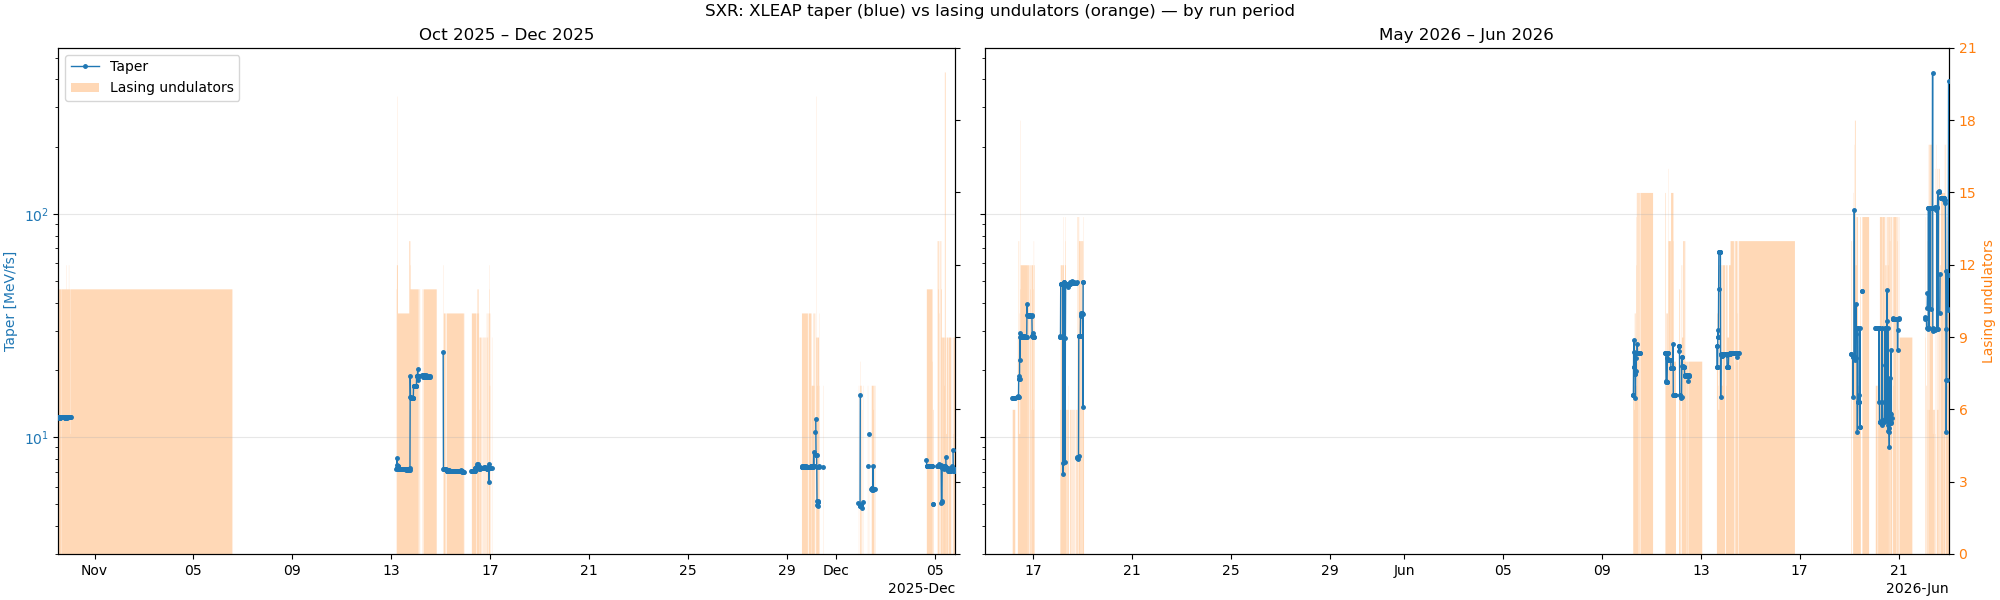

In [24]:
%matplotlib widget
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


def break_gaps(s, gap="6h"):
    """Insert NaN rows where sampling gaps exceed `gap`, so lines/fills don't bridge downtime."""
    brk = s.index[s.index.to_series().diff() > pd.Timedelta(gap)]
    if not len(brk):
        return s
    nans = pd.DataFrame(index=brk - pd.Timedelta("1s"), columns=s.columns)
    return pd.concat([s, nans]).sort_index()


df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()

PERIOD_GAP = pd.Timedelta("30D")      # gaps bigger than this = separate run -> own panel
periods = [g for _, g in df.groupby((df.index.to_series().diff() > PERIOD_GAP).cumsum())]
tmax = np.nanmax(df["taper"]); umax = int(df["n_und"].max()) + 1
spans = [max((g.index[-1] - g.index[0]).total_seconds(), 1) for g in periods]   # width ∝ real time

fig, axes = plt.subplots(1, len(periods), figsize=(20, 6), sharey=True,
                         constrained_layout=True, gridspec_kw={"width_ratios": spans})
axes = np.atleast_1d(axes); line = poly = None

for i, (ax_t, g) in enumerate(zip(axes, periods)):
    g = break_gaps(g)
    und_ax = ax_t.twinx()
    poly = und_ax.fill_between(g.index, g["n_und"].fillna(0), step="mid",
                               color="tab:orange", alpha=0.30, lw=0)
    (line,) = ax_t.plot(g.index, g["taper"], color="tab:blue", lw=1, marker="o", ms=2.5, zorder=5)
    ax_t.set_yscale("log"); ax_t.set_ylim(3, tmax * 1.3)
    und_ax.set_ylim(0, umax); und_ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax_t.set_zorder(und_ax.get_zorder() + 1); ax_t.patch.set_visible(False)

    ax_t.set_xlim(g.index.min(), g.index.max())
    loc = mdates.AutoDateLocator()
    ax_t.xaxis.set_major_locator(loc)
    ax_t.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax_t.grid(True, axis="y", alpha=0.3)
    ax_t.set_title(f"{g.index[0]:%b %Y} – {g.index[-1]:%b %Y}")

    if i == 0:                                        # taper label only on the far left
        ax_t.set_ylabel("Taper [MeV/fs]", color="tab:blue"); ax_t.tick_params(axis="y", labelcolor="tab:blue")
    if i == len(periods) - 1:                         # lasing label only on the far right
        und_ax.set_ylabel("Lasing undulators", color="tab:orange"); und_ax.tick_params(axis="y", labelcolor="tab:orange")
    else:
        und_ax.tick_params(axis="y", labelright=False)

fig.suptitle(f"{LINE.name}: XLEAP taper (blue) vs lasing undulators (orange) — by run period")
axes[0].legend([line, poly], ["Taper", "Lasing undulators"], loc="upper left")
plt.show()


/tmp/ipykernel_3226392/1836623671.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([s, nans]).sort_index()
/tmp/ipykernel_3226392/1836623671.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ax.fill_between(g.index, 0, 1, where=g["clearing"].fillna(False),
/tmp/ipykernel_3226392/1836623671.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, se

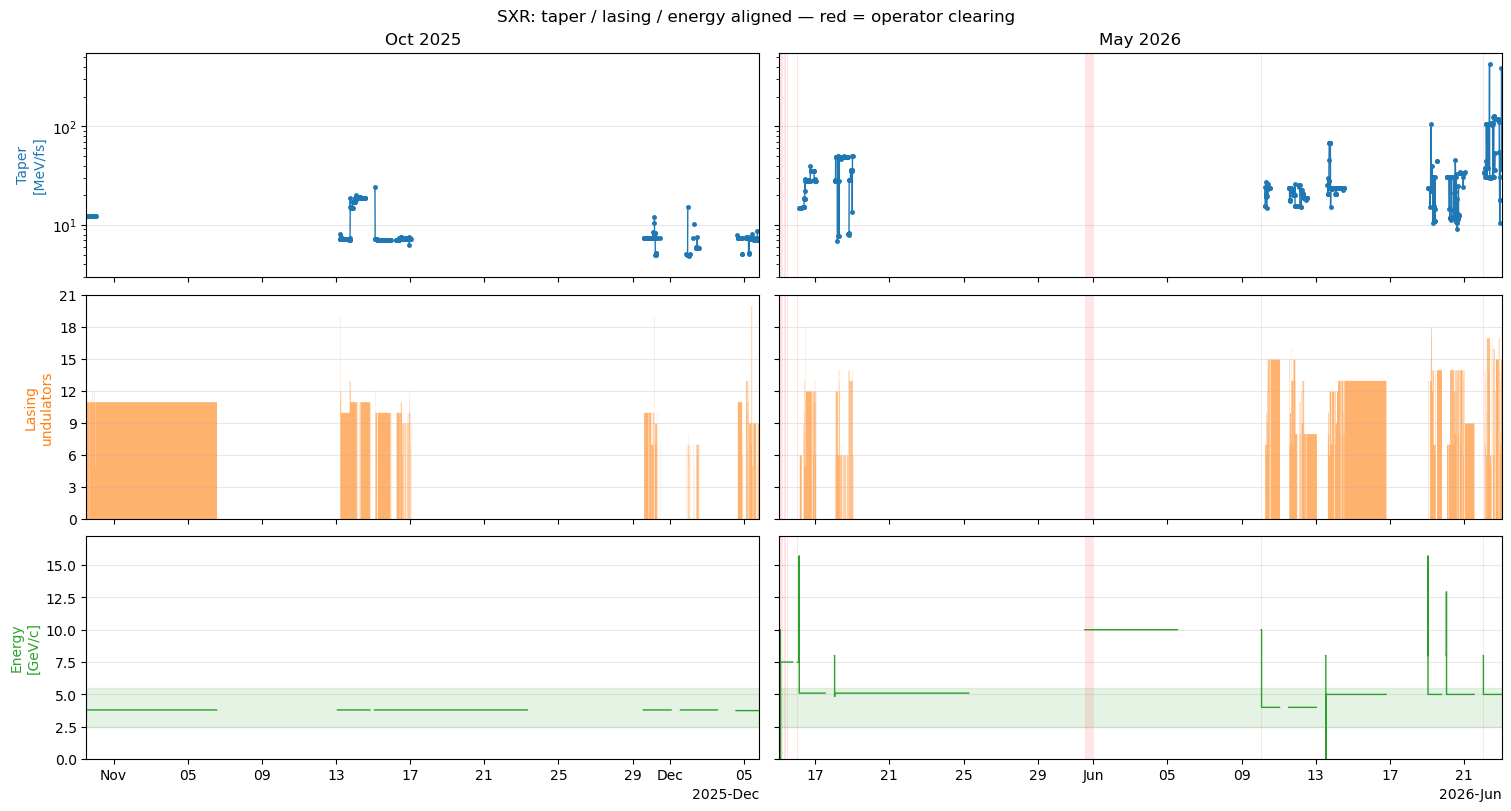

In [22]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


def break_gaps(s, gap="6h"):
    """Insert NaN rows where sampling gaps exceed `gap`, so lines/fills don't bridge downtime."""
    brk = s.index[s.index.to_series().diff() > pd.Timedelta(gap)]
    if not len(brk):
        return s
    nans = pd.DataFrame(index=brk - pd.Timedelta("1s"), columns=s.columns)
    return pd.concat([s, nans]).sort_index()


df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()
df["energy"]   = store.series(LINE.momentum_pv).reindex(df.index)
df["clearing"] = df["energy_implausible"] | df["energy_unsteady"]   # operator clearing / off-nominal
lo, hi = 2.5, 5.5                                                    # plausible SXR band (the gate)

PERIOD_GAP = pd.Timedelta("30D")
periods = [g for _, g in df.groupby((df.index.to_series().diff() > PERIOD_GAP).cumsum())]
tmax, umax, emax = np.nanmax(df["taper"]), int(df["n_und"].max()) + 1, np.nanmax(df["energy"]) * 1.1
spans = [max((g.index[-1] - g.index[0]).total_seconds(), 1) for g in periods]   # width ∝ real time

fig, axes = plt.subplots(3, len(periods), figsize=(15, 8), constrained_layout=True,
                         sharey="row", sharex="col", gridspec_kw={"width_ratios": spans})
axes = axes.reshape(3, len(periods))

for j, g in enumerate(periods):
    g = break_gaps(g)
    axt, axu, axe = axes[:, j]

    for ax in (axt, axu, axe):                                    # red = clearing, on all three
        ax.fill_between(g.index, 0, 1, where=g["clearing"].fillna(False),
                        transform=ax.get_xaxis_transform(), color="red", alpha=0.10, lw=0)
    axt.plot(g.index, g["taper"], color="tab:blue", lw=1, marker="o", ms=2.5)
    axt.set_yscale("log"); axt.set_ylim(3, tmax * 1.3)
    axu.fill_between(g.index, g["n_und"].fillna(0), step="mid", color="tab:orange", alpha=0.6, lw=0)
    axu.set_ylim(0, umax); axu.yaxis.set_major_locator(MaxNLocator(integer=True))
    axe.plot(g.index, g["energy"], color="tab:green", lw=1, drawstyle="steps-mid")
    axe.axhspan(lo, hi, color="tab:green", alpha=0.12); axe.set_ylim(0, emax)   # plausible band
    axt.set_title(f"{g.index[0]:%b %Y}")

    loc = mdates.AutoDateLocator()                      # set on bottom row; sharex="col" propagates up
    axe.xaxis.set_major_locator(loc)
    axe.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    axe.set_xlim(g.index.min(), g.index.max())
    for ax in (axt, axu, axe):
        ax.grid(True, axis="y", alpha=0.3)

axes[0, 0].set_ylabel("Taper\n[MeV/fs]", color="tab:blue")
axes[1, 0].set_ylabel("Lasing\nundulators", color="tab:orange")
axes[2, 0].set_ylabel("Energy\n[GeV/c]", color="tab:green")
fig.suptitle(f"{LINE.name}: taper / lasing / energy aligned — red = operator clearing")
plt.show()


In [23]:
%matplotlib widget
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


def break_gaps(s, gap="6h"):
    """Insert NaN rows where sampling gaps exceed `gap`, so lines/fills don't bridge downtime."""
    brk = s.index[s.index.to_series().diff() > pd.Timedelta(gap)]
    if not len(brk):
        return s
    nans = pd.DataFrame(index=brk - pd.Timedelta("1s"), columns=s.columns)
    return pd.concat([s, nans]).sort_index()


df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()
df["energy"] = store.series(LINE.momentum_pv).reindex(df.index)
d = break_gaps(df)

fig, ax_u = plt.subplots(figsize=(15, 6), constrained_layout=True)   # base = orange (BACK)
ax_t = ax_u.twinx()                                                  # blue  (MID)
ax_e = ax_u.twinx()                                                  # green (TOP)
ax_e.spines["right"].set_position(("axes", 1.07))                    # offset the 3rd axis out

ax_u.set_zorder(1); ax_t.set_zorder(2); ax_e.set_zorder(3)           # <-- the layering
ax_t.patch.set_visible(False); ax_e.patch.set_visible(False)         # let back layers show through

# BACK — lasing (orange area, left axis)
p_u = ax_u.fill_between(d.index, d["n_und"].fillna(0), step="mid", color="tab:orange", alpha=0.35, lw=0)
ax_u.set_ylim(0, int(df["n_und"].max()) + 1); ax_u.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_u.set_ylabel("Lasing undulators", color="tab:orange"); ax_u.tick_params(axis="y", labelcolor="tab:orange")

# MID — taper (blue line, log, right axis)
(l_t,) = ax_t.plot(d.index, d["taper"], color="tab:blue", lw=1.2, marker="o", ms=2.5)
ax_t.set_yscale("log"); ax_t.set_ylim(3, np.nanmax(df["taper"]) * 1.3)
ax_t.set_ylabel("Taper [MeV/fs]", color="tab:blue"); ax_t.tick_params(axis="y", labelcolor="tab:blue")

# TOP — energy (green line, offset right axis)
(l_e,) = ax_e.plot(d.index, d["energy"], color="tab:green", lw=1.2, drawstyle="steps-mid")
ax_e.set_ylim(0, np.nanmax(df["energy"]) * 1.1)
ax_e.set_ylabel("Energy [GeV/c]", color="tab:green"); ax_e.tick_params(axis="y", labelcolor="tab:green")

loc = mdates.AutoDateLocator()                          # zooms adaptively in the widget backend
ax_u.xaxis.set_major_locator(loc)
ax_u.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
ax_u.set_xlabel("Time (UTC)")
ax_t.legend([p_u, l_t, l_e], ["Lasing undulators", "Taper", "Energy"], loc="upper left")
ax_u.set_title(f"{LINE.name}: lasing (orange · back) — taper (blue · mid) — energy (green · top)")
plt.show()


/tmp/ipykernel_3226392/3205459805.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([s, nans]).sort_index()
/tmp/ipykernel_3226392/3205459805.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  p_u = ax_u.fill_between(d.index, d["n_und"].fillna(0), step="mid", color="tab:orange", alpha=0.35, lw=0)


KeyboardInterrupt: 

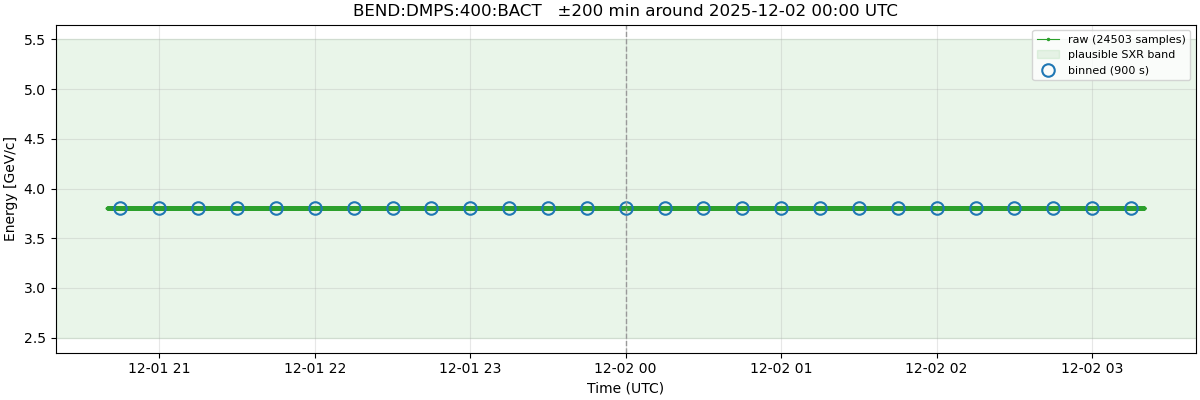

2025-12-01 20:39:59    3.800000
2025-12-01 20:40:00    3.800008
2025-12-01 20:40:01    3.800002
2025-12-01 20:40:02    3.800000
2025-12-01 20:40:03    3.799995
                         ...   
2025-12-02 03:19:55    3.800002
2025-12-02 03:19:56    3.800000
2025-12-02 03:19:58    3.800000
2025-12-02 03:19:59    3.799997
2025-12-02 03:19:59    3.800006
Length: 24503, dtype: float64

In [17]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from snapshots.archive import _get_series
from snapshots.config import RunConfig

def zoom_energy(center, half_minutes=60, pv=None, protocol="HTTP", show_binned=True):
    """Pull RAW beam momentum around `center` and plot the real trace
    (plateau -> clearing sine -> new energy). Hits the archiver, so run on the
    SLAC network. `center` is any UTC datetime-like, e.g. a suspicious taper time."""
    pv  = pv or LINE.momentum_pv
    c   = pd.Timestamp(center)
    fmt = "%Y-%m-%dT%H:%M:%S.000Z"
    cfg = RunConfig(from_time=(c - pd.Timedelta(minutes=half_minutes)).strftime(fmt),
                    to_time  =(c + pd.Timedelta(minutes=half_minutes)).strftime(fmt),
                    operator="", protocol=protocol)          # operator="" -> raw samples
    try:
        secs, vals = _get_series(pv, cfg)
    except Exception as e:
        print(f"no raw data for {pv} around {c}: {e}"); return None
    s = pd.Series(np.asarray(vals, float),
                  index=pd.to_datetime(np.asarray(secs, "int64"), unit="s")).sort_index()

    fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
    ax.plot(s.index, s.values, marker=".", ms=3, lw=0.8, color="tab:green",
            label=f"raw ({len(s)} samples)")
    ax.axhspan(2.5, 5.5, color="tab:green", alpha=0.10, label="plausible SXR band")
    if show_binned:                                          # what the timeline/gate actually uses
        b = store.series(pv); b = b[(b.index >= s.index.min()) & (b.index <= s.index.max())]
        if len(b):
            ax.plot(b.index, b.values, "o", ms=9, mfc="none", mec="tab:blue", mew=1.5,
                    label="binned (900 s)")
    ax.axvline(c, color="0.6", ls="--", lw=1)
    ax.set_ylabel("Energy [GeV/c]"); ax.set_xlabel("Time (UTC)")
    ax.set_title(f"{pv}   \u00b1{half_minutes} min around {c:%Y-%m-%d %H:%M} UTC")
    ax.grid(True, alpha=0.3); ax.legend(loc="upper right", fontsize=8)
    plt.show()
    return s
zoom_energy("2025-12-02 00:00", half_minutes=200)   # the 426 MeV/fs taper — is it a clearing sine?


## 5. Validation and investigation

The June 2026 SXR timeline shows a clean $\sim20$ MeV/fs XLEAP band plus a handful of extreme spikes up to $\sim730$ MeV/fs. This section establishes what those spikes are, confirms the motion filter neither misses real motion nor discards real XLEAP, and settles the motion-threshold choice with data.

The cell below builds the "with filter" (`after`) and "without filter" (`before`) timelines from the same data (the latter by forcing every `moved` flag to `False`), so we can see exactly what the motion filter removes.

In [9]:
import dataclasses

after   = timeline_frame(xleap_timeline(store, line=LINE))                                     # filter ON
before  = timeline_frame(xleap_timeline(
    dataclasses.replace(store, frame=store.frame.assign(moved=False)), line=LINE))             # filter OFF
kvals   = store.wide_values(LINE.kact_pattern)
moved   = store.wide_moved(LINE.kact_pattern)
mom     = store.series(LINE.momentum_pv).reindex(after.index)
removed = before.index[before["xleap_on"] & ~after["xleap_on"]]

print(f"snapshots           : {len(after)}")
print(f"XLEAP-on (filtered) : {int(after['xleap_on'].sum())}")
print(f"moved cells total   : {int(store.frame['moved'].sum())}")
print(f"times any-moving    : {int(moved.any(axis=1).sum())} / {len(moved)}")
print(f"removed by filter   : {len(removed)}")

snapshots           : 1463
XLEAP-on (filtered) : 963
moved cells total   : 923
times any-moving    : 132 / 1463
removed by filter   : 109


### 5.1 Motion filter: rule and effect

**Motion rule (per Aaron).** For each nominal time an undulator has *moved* when the fractional spread of its raw samples inside a 5 s window exceeds a threshold $\tau$:
$$
\frac{\max - \min}{\lvert\mathrm{median}\rvert} > \tau \quad(\tau = 10^{-3}),\qquad \le 1\ \text{sample} \Rightarrow \text{stationary (thermal noise)}.
$$
If **any** undulator moved at a given time, that time is force-cleared: `xleap_on = False`, `taper = NaN`, `moving = True`, kept visible rather than dropped.

The figure overlays **before** (motion off, grey) and **after** (motion on, blue/orange); red crosses mark points the filter removed. A correct filter removes only slew/transition points and leaves the stable lasing blocks, and crucially the large spikes, untouched.

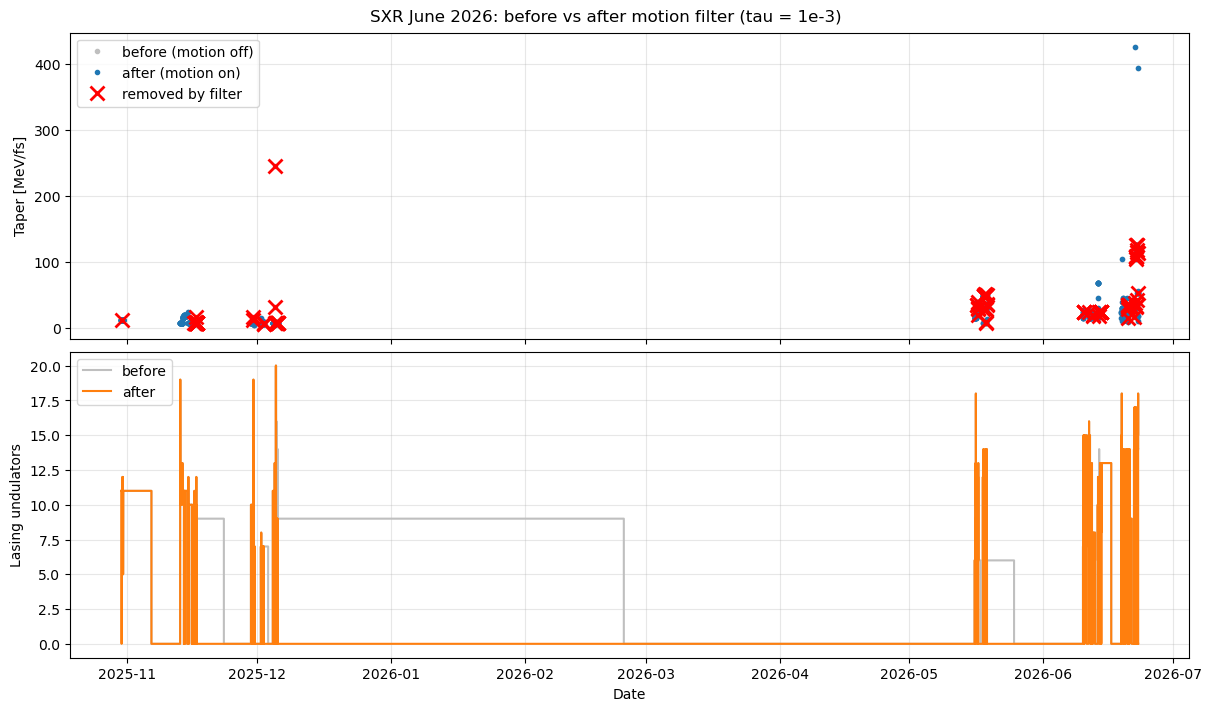

In [11]:
fig, (ax_t, ax_n) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
ax_t.plot(before.index, before["taper"], "o", ms=3, color="0.75", label="before (motion off)")
ax_t.plot(after.index,  after["taper"],  "o", ms=3, color="tab:blue", label="after (motion on)")
if len(removed):
    ax_t.plot(removed, before.loc[removed, "taper"], "x", color="red", ms=10, mew=2, label="removed by filter")
ax_t.set_ylabel("Taper [MeV/fs]"); ax_t.grid(alpha=0.3); ax_t.legend(loc="upper left")
ax_n.step(before.index, before["n_und"], where="mid", color="0.75", label="before")
ax_n.step(after.index,  after["n_und"],  where="mid", color="tab:orange", label="after")
ax_n.set_ylabel("Lasing undulators"); ax_n.set_xlabel("Date"); ax_n.grid(alpha=0.3); ax_n.legend(loc="upper left")
fig.suptitle(f"{LINE.name} June 2026: before vs after motion filter (tau = 1e-3)")
plt.show()

**Observation.** The red crosses land only on the normal $\sim20$ MeV/fs band, at the edges of lasing blocks, where undulators are slewing in or out of a configuration. The large spikes carry no red cross: the motion filter does not touch them. That is the first clue that the spikes are not a motion phenomenon.

### 5.2 The largest spike is stationary, not moving

We drill into the single worst point. Its summary and full $K$ profile follow.

In [ ]:
sp = after["taper"].idxmax()
display(pd.DataFrame({
    "time": [sp],
    "taper [MeV/fs]": [round(float(after.loc[sp, "taper"]), 1)],
    "beam [GeV/c]": [round(float(mom.loc[sp]), 3)],
    "n_und": [int(after.loc[sp, "n_und"])],
    "moving": [bool(after.loc[sp, "moving"])],
}))

,time,taper [MeV/fs],beam [GeV/c],n_und,moving
0,2026-06-22 09:00:00,426.2,5.0,5,False


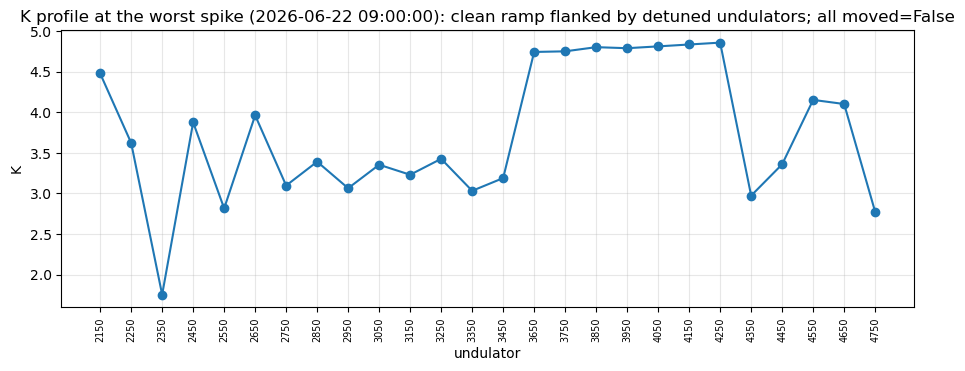

In [ ]:
ks = kvals.loc[sp]
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(range(len(ks)), ks.values, "o-")
ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks.index, rotation=90, fontsize=7)
ax.set_ylabel("K"); ax.set_xlabel("undulator")
ax.set_title(f"K profile at the worst spike ({sp}): clean ramp flanked by detuned undulators; all moved=False")
ax.grid(alpha=0.3); plt.show()

**The profile tells the whole story.** A clean, monotonic $K$-ramp occupies the middle undulators (here $K\approx5.3$), but it is flanked by heavily detuned undulators ($K$ roughly 1 to 3.7) that are clearly parked, not lasing. Every undulator reports `moved = False`: the Ks are stationary. This is Aaron's "Ks in place, but the beam energy wasn't there yet." A 5 s motion window can never flag it, because there is no motion to flag. We verified separately that even a 10 times tighter threshold ($\tau=10^{-4}$) leaves this point `moving = False`.

### 5.3 The spikes correlate with off-nominal beam energy

If the spikes are a beam-energy artefact, they should occur when the machine is not at the soft line's normal operating energy. Splitting the XLEAP-on points by taper magnitude and summarising the beam momentum confirms it, and the scatter makes the $\gamma^3$ inflation visible.

In [ ]:
on = after["xleap_on"]
tbl = pd.concat({
    "real (taper <= 100)":    mom[on & (after["taper"] <= 100)].describe(),
    "spurious (taper > 100)": mom[on & (after["taper"] >  100)].describe(),
}, axis=1)
display(tbl.round(2))

,real (taper <= 100),spurious (taper > 100)
count,920.00,43.0
mean,4.31,5.0
std,0.60,0.0
min,3.75,5.0
25%,3.80,5.0
50%,4.00,5.0
75%,5.00,5.0
max,5.10,5.0


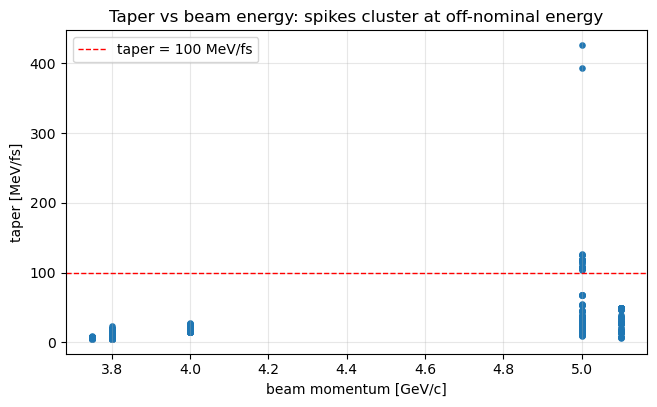

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(mom[on], after["taper"][on], s=14, color="tab:blue")
ax.axhline(100, color="red", ls="--", lw=1, label="taper = 100 MeV/fs")
ax.set_xlabel("beam momentum [GeV/c]"); ax.set_ylabel("taper [MeV/fs]")
ax.set_title("Taper vs beam energy: spikes cluster at off-nominal energy")
ax.grid(alpha=0.3); ax.legend()
plt.show()

**Result.** The real XLEAP band sits in a tight 4 to 5 GeV/c cluster; the $>100$ MeV/fs spikes occur at 5 to 15.7 GeV/c (median about 8). Combined with the $\gamma^3$ scaling of Section 2.1, an ordinary $\Delta K\approx0.02$, $K\approx4$ to $5$ ramp inflates into hundreds of MeV/fs. The spikes are detection false positives in an off-nominal beam state, not motion, and not a taper-math error.

Note the overlap: the spurious set reaches down to 5 GeV/c and the real set up to 10 GeV/c, and XLEAP legitimately runs at 8 to 10 GeV. A flat energy cut or a flat taper ceiling would therefore clip real high-energy XLEAP; the correct discriminator is a resonance/energy-match condition (Section 6).

### 5.4 Motion-threshold study: $10^{-3}$ vs $10^{-4}$

David asked whether the motion threshold should be $10^{-3}$ or $10^{-4}$. Each value is baked into the `moved` column at fetch time, so the two rows below come from separate fetches and are recorded here as constants (they are not recomputed from the currently-loaded CSV). Both thresholds remove only real-band points, never the spikes.

In [ ]:
sweep = pd.DataFrame([
    {"threshold": "1e-3 (recommended)", "removed": 25, "real_XLEAP_removed": 25,
     "isolated_transitions": 18, "in_runs": 6, "note": "only slew/transition points removed"},
    {"threshold": "1e-4",               "removed": 33, "real_XLEAP_removed": 33,
     "isolated_transitions": None, "in_runs": None, "note": "8 extra removals are sub-0.1%, i.e. thermal"},
])
display(sweep)

,threshold,removed,real_XLEAP_removed,isolated_transitions,in_runs,note
0,1e-3 (recommended),25,25,18.0,6.0,only slew/transition points removed
1,1e-4,33,33,NaN,NaN,"8 extra removals are sub-0.1%, i.e. thermal"


**Decision: $\tau = 10^{-3}$.** Going to $10^{-4}$ removes 8 additional real XLEAP points, and by construction those 8 have fractional change between $10^{-4}$ and $10^{-3}$, i.e. sub-$0.1\%$, squarely in the thermal-noise regime the rule is meant to ignore. So $10^{-4}$ starts labelling thermal jitter as motion and eats real XLEAP; $10^{-3}$ removes only the clearly-moving points.

At $10^{-3}$ the 25 removals split into 18 isolated transitions (clean) and 6 that fall in short consecutive runs. The latter are real-band XLEAP points ($n_\text{und}=7$ to 15, taper 14 to 25) removed because an undulator crossed threshold at that moment, rule-consistent but a small, non-zero loss worth flagging:

In [ ]:
in_runs = pd.DataFrame([
    ("2026-06-10 12:30", 15, 23.6), ("2026-06-10 12:45", 15, 23.9),
    ("2026-06-13 23:30",  7, 23.5), ("2026-06-13 23:45", 14, 18.4),
    ("2026-06-14 12:00",  9, 24.5), ("2026-06-20 17:30", 14, 14.2),
], columns=["time", "n_und_before", "taper_before"])
display(in_runs)

,time,n_und_before,taper_before
0,2026-06-10 12:30,15,23.6
1,2026-06-10 12:45,15,23.9
2,2026-06-13 23:30,7,23.5
3,2026-06-13 23:45,14,18.4
4,2026-06-14 12:00,9,24.5
5,2026-06-20 17:30,14,14.2


## 6. Discussion and open questions

**What is settled.**
- The pipeline reconstructs XLEAP, the lasing undulators, and the taper, and reproduces the reference SXR results.
- The motion filter works: at $\tau=10^{-3}$ it removes 25 points (18 isolated transitions and 6 real-band points during genuine undulator motion) and loses no stable XLEAP.
- The high-taper spikes are not motion (stationary Ks at any threshold) but detection false positives at off-nominal beam energy, amplified by the $\gamma^3$ dependence.

**Open questions (for David).**
1. **Resonance / energy-match gate.** Reject "Ks tapered but beam not at the lasing energy." It must still admit real 8 to 10 GeV XLEAP, so it cannot be a flat energy or taper cap. Natural form: require the group's $K$ to be near the resonant $K$ for the measured $\gamma$ and target photon energy (needs $\lambda_u$ or photon energy; the reference cites SXR at 39 mm / 530 eV).
2. **The $\gamma^3$ dependence** in the taper formula: confirm it is physically correct as derived (Section 2.1); it is what turns an ordinary $\Delta K$ into $\sim730$ MeV/fs at 15.7 GeV/c.
3. **Detection threshold metric.** Detection currently thresholds the *absolute* step $\Delta K \ge 4\rho$ (matching the reference notebook); should it instead threshold the *relative* $\Delta K/K$?
4. **Motion threshold.** Recommend $10^{-3}$, justified by Section 5.4.
5. **Record motion magnitude.** Have the fetch store the fractional spread $(\max-\min)/\mathrm{median}$ per bin, not just the `moved` boolean, so borderline points (the 6 in Section 5.4) can be judged and the threshold tuned without re-fetching.

**Appendix.** The full unit and smoke suite lives in [`test_taper.py`](test_taper.py) (`python test_taper.py`): physics identities, store pivots, detection, the XLEAP timeline, and the motion filter.